# Robustness across random seeds (rs100)

💡 **Environment:** `clamp-analyses`  

Evaluate whether the three CLAMP models trained on different random seeds (`hall_coverage_rs100_seed_{1,2,3}`) recover reproducible latent variables and pathways.

Two analyses:
1. **LV similarity**: compare the Z (gene-loading) matrices using Pearson, Spearman, and Jaccard (top 1% genes). For each LV find its best match in every other model and report global scores + heatmaps.
2. **Pathway overlap**: filter `summary` (FDR < 0.05, AUC > 0.7) and visualise shared pathways across seeds with an UpSet plot.

In [1]:
library(here)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)
library(RColorBrewer)
library(Matrix)

output_dir <- here("output/03_model_biology/00_archs4/10_archs4_robutsness/00_robutsness")

theme_ng <- function() {
  theme_classic(base_size = 16) +
    theme(
      axis.title       = element_text(size = 18, colour = "black"),
      axis.title.y     = element_text(margin = margin(r = 14)),
      axis.text        = element_text(size = 14, colour = "black"),
      axis.line        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks       = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.20, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.6),
      panel.grid.minor   = element_blank(),
      legend.position  = "right",
      strip.background = element_blank(),
      strip.text       = element_text(face = "bold", size = 16),
      plot.margin      = margin(t = 12, r = 10, b = 10, l = 36)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




## Load models

In [2]:
seeds  <- 1:3
models <- lapply(seeds, function(s) {
  path <- file.path(output_dir,
                    sprintf("hall_coverage_rs100_seed_%d", s),
                    "CLAMPfull_hall.rds")
  message("Loading ", path)
  readRDS(path)
})
names(models) <- paste0("seed_", seeds)

for (nm in names(models)) {
  m <- models[[nm]]
  message(nm, ": K=", ncol(m$Z), "  genes=", nrow(m$Z),
          "  samples=", ncol(m$B))
}

Loading /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/10_archs4_robutsness/00_robutsness/hall_coverage_rs100_seed_1/CLAMPfull_hall.rds

Loading /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/10_archs4_robutsness/00_robutsness/hall_coverage_rs100_seed_2/CLAMPfull_hall.rds

Loading /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/10_archs4_robutsness/00_robutsness/hall_coverage_rs100_seed_3/CLAMPfull_hall.rds

seed_1: K=1728  genes=18423  samples=605614

seed_2: K=1728  genes=18423  samples=605614

seed_3: K=1728  genes=18423  samples=605614



---
## 1. LV similarity: Z matrix

For each pair of seeds and two gene-percentage thresholds (**1%** and **5%**):

- **Top genes per LV**: genes are ranked by descending loading; the top k% are selected per LV.
- **Pearson / Spearman**: computed on the loading values of the reference LV's top-k% genes, matched by gene name in the target LV.
- **Jaccard**: binary set overlap of the top-k% gene sets.

For each LV in model A the **best-match score** = max similarity to any LV in model B.  
The **global score** = mean of best-match scores across all LVs in A (averaged A→B and B→A).

In [3]:
# Extract dense Z matrices (genes x LVs) and restrict to common genes
Z_list <- lapply(models, function(m) as.matrix(m$Z))

common_genes <- Reduce(intersect, lapply(Z_list, rownames))
message("Common genes across 3 seeds: ", length(common_genes))

Z_list <- lapply(Z_list, function(Z) Z[common_genes, ])

n_genes <- nrow(Z_list[[1]])
message(sprintf("Gene counts at each threshold: total: %d  |  top 1%%: %d  |  top 5%%: %d",
                n_genes, ceiling(n_genes * 0.01), ceiling(n_genes * 0.05)))

for (nm in names(Z_list)) {
  message(nm, ": ", nrow(Z_list[[nm]]), " genes x ", ncol(Z_list[[nm]]), " LVs")
}

Common genes across 3 seeds: 18423

Gene counts at each threshold: total: 18423  |  top 1%: 185  |  top 5%: 922

seed_1: 18423 genes x 1728 LVs

seed_2: 18423 genes x 1728 LVs

seed_3: 18423 genes x 1728 LVs



In [4]:
# ── helper functions ──────────────────────────────────────────────────────────
#
# All metrics use the top k% genes (by loading) of the REFERENCE LV.
# Pearson / Spearman: loading values matched by gene name.
# Jaccard: binary set overlap of top-k% gene sets.
#
# For each LV_i in Za, genes are ordered descending, top n_top are selected.
# Those genes' loadings are extracted from every LV in Zb and correlation is computed.

# Pearson or Spearman cross-similarity matrix (Ka x Kb)
# LVs with zero variance in their top-k% genes return NA without warnings.
CrossCorTopK <- function(Za, Zb, pct = 0.01, method = "pearson") {
  stopifnot(!is.null(rownames(Za)), !is.null(rownames(Zb)))

  common_genes <- intersect(rownames(Za), rownames(Zb))
  if (length(common_genes) == 0) stop("Za and Zb do not share any gene names.")

  Za <- Za[common_genes, , drop = FALSE]
  Zb <- Zb[common_genes, , drop = FALSE]

  n_top  <- max(1, ceiling(nrow(Za) * pct))
  Ka     <- ncol(Za)
  Kb     <- ncol(Zb)
  result <- matrix(
    NA_real_,
    nrow = Ka,
    ncol = Kb,
    dimnames = list(colnames(Za), colnames(Zb))
  )

  for (i in seq_len(Ka)) {
    g_idx  <- order(Za[, i], decreasing = TRUE)[seq_len(n_top)]
    genes  <- rownames(Za)[g_idx]
    lv_ref <- Za[genes, i]

    if (all(is.na(lv_ref)) || sd(lv_ref, na.rm = TRUE) == 0) next

    Y <- Zb[genes, , drop = FALSE]
    y_sd <- apply(Y, 2, sd, na.rm = TRUE)
    ok   <- !is.na(y_sd) & y_sd > 0

    if (any(ok)) {
      result[i, ok] <- as.numeric(
        cor(
          matrix(lv_ref, ncol = 1),
          Y[, ok, drop = FALSE],
          method = method,
          use = "pairwise.complete.obs"
        )
      )
    }
  }

  result
}

# Vectorised Jaccard (Ka x Kb) using matrix multiplication
JaccardCrossSimMat <- function(Za, Zb, pct = 0.01) {
  stopifnot(!is.null(rownames(Za)), !is.null(rownames(Zb)))

  common_genes <- intersect(rownames(Za), rownames(Zb))
  if (length(common_genes) == 0) stop("Za and Zb do not share any gene names.")

  Za <- Za[common_genes, , drop = FALSE]
  Zb <- Zb[common_genes, , drop = FALSE]

  MakeBinaryMat <- function(Z) {
    out <- sapply(seq_len(ncol(Z)), function(j) {
      lv <- Z[, j]
      thresh <- quantile(lv, 1 - pct, na.rm = TRUE, names = FALSE)
      as.integer(lv >= thresh)
    })
    if (is.vector(out)) {
      out <- matrix(out, ncol = 1)
      colnames(out) <- colnames(Z)
    }
    rownames(out) <- rownames(Z)
    out
  }

  Ma <- MakeBinaryMat(Za)
  Mb <- MakeBinaryMat(Zb)

  inter     <- t(Ma) %*% Mb
  union_mat <- outer(colSums(Ma), colSums(Mb), "+") - inter
  inter / union_mat
}

# Best-match score per LV in A (max similarity to any LV in B); all-NA rows stay NA
BestMatchScores <- function(sim_mat) {
  apply(sim_mat, 1, function(x) {
    if (all(is.na(x))) NA_real_ else max(x, na.rm = TRUE)
  })
}

message("Helper functions defined.")

Helper functions defined.



---
### Top 1% genes per LV

In [5]:
pair_idx  <- list(c(1, 2), c(1, 3), c(2, 3))
pair_labs <- c("Seed 1 vs 2", "Seed 1 vs 3", "Seed 2 vs 3")

sim_1pct    <- list()
global_rows <- list()

for (k in seq_along(pair_idx)) {
  i <- pair_idx[[k]][1];  j <- pair_idx[[k]][2];  lab <- pair_labs[k]
  Za <- Z_list[[i]];      Zb <- Z_list[[j]]

  message("[1% | ", lab, "]")
  message("  Pearson ...")
  pc_mat <- CrossCorTopK(Za, Zb, pct = 0.01, method = "pearson")
  message("  Spearman ...")
  sp_mat <- CrossCorTopK(Za, Zb, pct = 0.01, method = "spearman")
  message("  Jaccard ...")
  jc_mat <- JaccardCrossSimMat(Za, Zb, pct = 0.01)

  sim_1pct[[lab]] <- list(pearson = pc_mat, spearman = sp_mat, jaccard = jc_mat)

  global_rows[[k]] <- data.frame(
    pair            = lab,
    pearson_global  = mean(c(BestMatchScores(pc_mat), BestMatchScores(t(pc_mat)))),
    spearman_global = mean(c(BestMatchScores(sp_mat), BestMatchScores(t(sp_mat)))),
    jaccard_global  = mean(c(BestMatchScores(jc_mat), BestMatchScores(t(jc_mat)))),
    stringsAsFactors = FALSE
  )
  message(sprintf("  → Pearson=%.3f  Spearman=%.3f  Jaccard=%.3f",
                  global_rows[[k]]$pearson_global,
                  global_rows[[k]]$spearman_global,
                  global_rows[[k]]$jaccard_global))
}

global_df_1pct <- do.call(rbind, global_rows)
rownames(global_df_1pct) <- NULL
print(global_df_1pct)

[1% | Seed 1 vs 2]

  Pearson ...

  Spearman ...

  Jaccard ...

  → Pearson=0.750  Spearman=0.423  Jaccard=0.263

[1% | Seed 1 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...

  → Pearson=0.752  Spearman=0.426  Jaccard=0.265

[1% | Seed 2 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...

  → Pearson=0.751  Spearman=0.419  Jaccard=0.263



         pair pearson_global spearman_global jaccard_global
1 Seed 1 vs 2      0.7502049       0.4229684      0.2626590
2 Seed 1 vs 3      0.7515177       0.4258605      0.2652083
3 Seed 2 vs 3      0.7513150       0.4189468      0.2625325


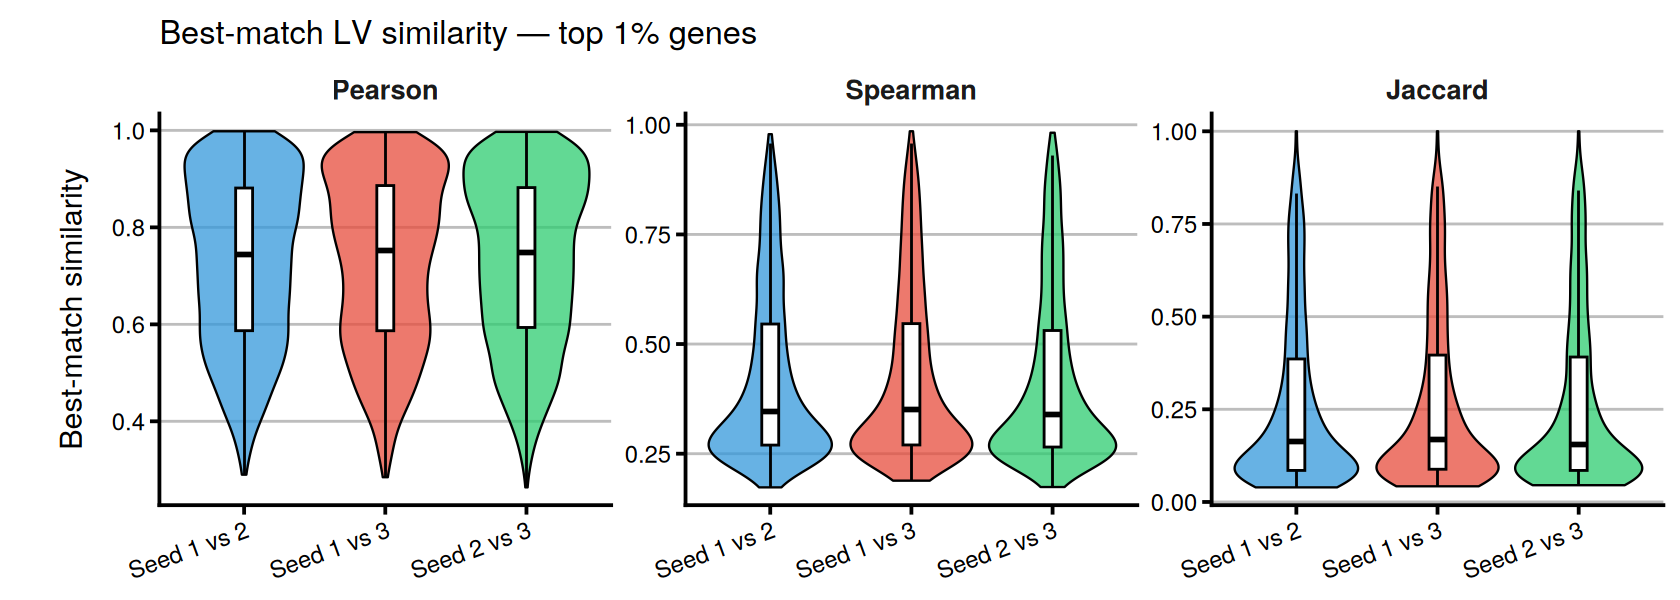

In [6]:
pal <- c("Seed 1 vs 2" = "#3498db", "Seed 1 vs 3" = "#e74c3c", "Seed 2 vs 3" = "#2ecc71")

bm_long_1pct <- bind_rows(lapply(pair_labs, function(lab) {
  sm <- sim_1pct[[lab]]
  bind_rows(
    data.frame(pair = lab, method = "Pearson",  score = BestMatchScores(sm$pearson)),
    data.frame(pair = lab, method = "Spearman", score = BestMatchScores(sm$spearman)),
    data.frame(pair = lab, method = "Jaccard",  score = BestMatchScores(sm$jaccard))
  )
}))
bm_long_1pct$method <- factor(bm_long_1pct$method, levels = c("Pearson", "Spearman", "Jaccard"))
bm_long_1pct$pair   <- factor(bm_long_1pct$pair,   levels = pair_labs)

options(repr.plot.width = 14, repr.plot.height = 5)
ggplot(bm_long_1pct, aes(x = pair, y = score, fill = pair)) +
  geom_violin(trim = TRUE, alpha = 0.75, colour = "black", linewidth = 0.5) +
  geom_boxplot(width = 0.12, fill = "white", colour = "black",
               linewidth = 0.6, outlier.shape = NA) +
  facet_wrap(~method, scales = "free_y") +
  scale_fill_manual(values = pal) +
  labs(x = NULL, y = "Best-match similarity",
       title = "Best-match LV similarity: top 1% genes") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 20, hjust = 1), legend.position = "none")

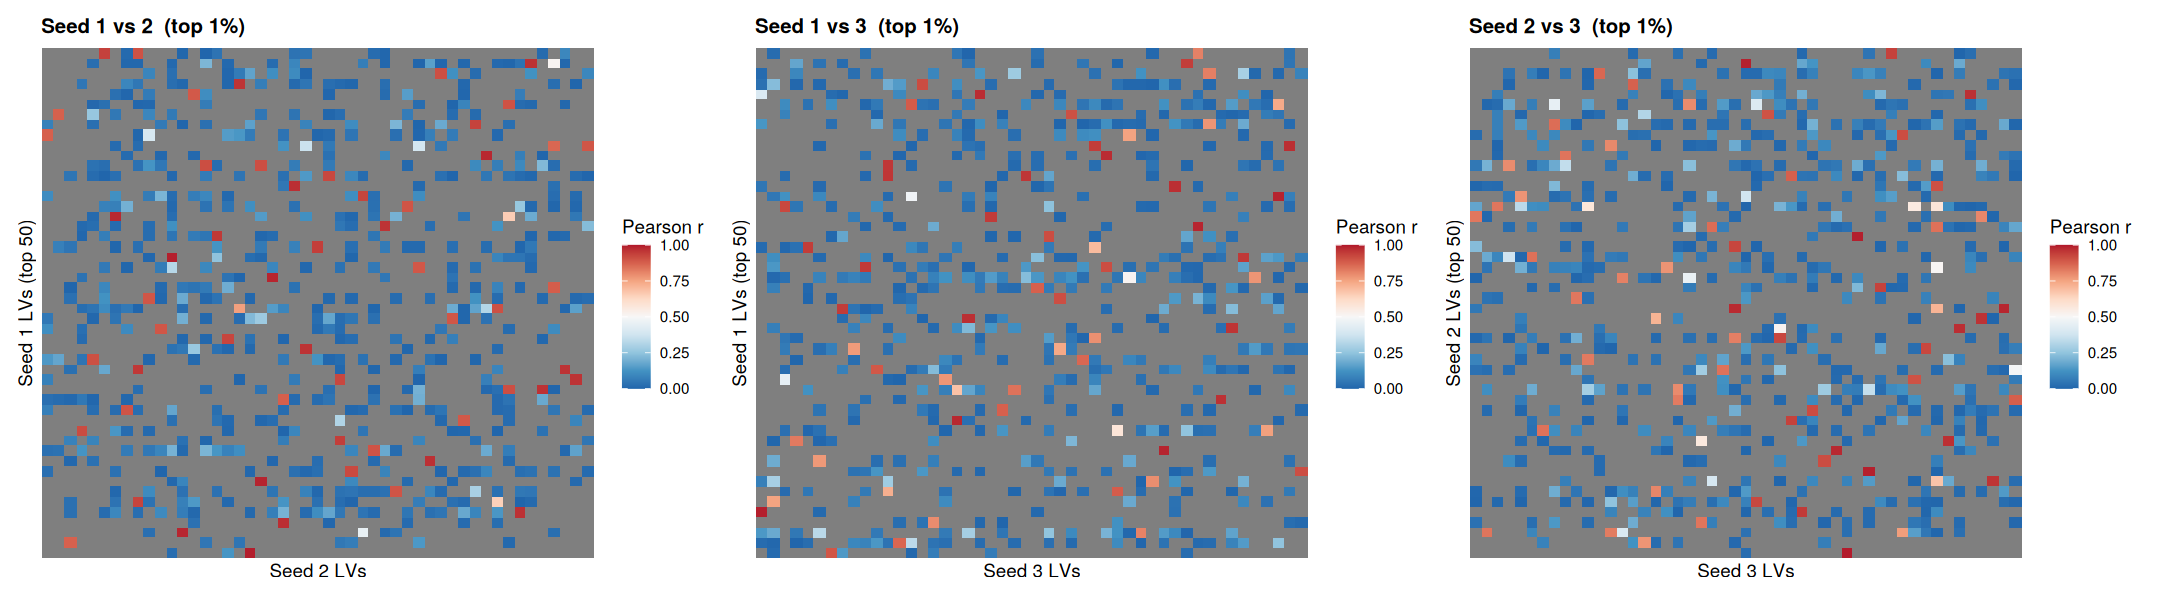

In [7]:
TOP_N <- 50
MakeTopHeatmapDF <- function(pc_mat, top_n = TOP_N) {
  bm_scores <- apply(pc_mat, 1, max)
  bm_idx    <- apply(pc_mat, 1, which.max)
  top_a     <- order(bm_scores, decreasing = TRUE)[seq_len(top_n)]
  top_b     <- unique(bm_idx[top_a])[seq_len(min(top_n, length(unique(bm_idx[top_a]))))]
  sub_mat   <- pc_mat[top_a, top_b]
  rownames(sub_mat) <- paste0("A_LV", top_a)
  colnames(sub_mat) <- paste0("B_LV", top_b)
  df <- as.data.frame(sub_mat);  df$lv_a <- rownames(df)
  tidyr::pivot_longer(df, cols = -lv_a, names_to = "lv_b", values_to = "cor")
}

hp_1pct <- lapply(seq_along(pair_idx), function(k) {
  i <- pair_idx[[k]][1];  j <- pair_idx[[k]][2];  lab <- pair_labs[k]
  df <- MakeTopHeatmapDF(sim_1pct[[lab]]$pearson, TOP_N)
  sub     <- matrix(df$cor, nrow = length(unique(df$lv_a)), ncol = length(unique(df$lv_b)),
                    dimnames = list(unique(df$lv_a), unique(df$lv_b)))
  df$lv_a <- factor(df$lv_a, levels = rownames(sub)[hclust(dist(sub))$order])
  df$lv_b <- factor(df$lv_b, levels = colnames(sub)[hclust(dist(t(sub)))$order])
  ggplot(df, aes(x = lv_b, y = lv_a, fill = cor)) +
    geom_tile(colour = NA) +
    scale_fill_gradientn(colours = rev(RColorBrewer::brewer.pal(9, "RdBu")),
                         limits = c(0, 1), name = "Pearson r") +
    labs(title = paste0(lab, "  (top 1%)"),
         x = paste0("Seed ", j, " LVs"), y = paste0("Seed ", i, " LVs (top ", TOP_N, ")")) +
    theme_classic(base_size = 11) +
    theme(axis.text = element_blank(), axis.ticks = element_blank(),
          axis.line = element_blank(), plot.title = element_text(face = "bold", size = 12))
})

options(repr.plot.width = 18, repr.plot.height = 5)
wrap_plots(hp_1pct, nrow = 1)

---
### Top 5% genes per LV

In [8]:
sim_5pct    <- list()
global_rows <- list()

for (k in seq_along(pair_idx)) {
  i <- pair_idx[[k]][1];  j <- pair_idx[[k]][2];  lab <- pair_labs[k]
  Za <- Z_list[[i]];      Zb <- Z_list[[j]]

  message("[5% | ", lab, "]")
  message("  Pearson ...")
  pc_mat <- CrossCorTopK(Za, Zb, pct = 0.05, method = "pearson")
  message("  Spearman ...")
  sp_mat <- CrossCorTopK(Za, Zb, pct = 0.05, method = "spearman")
  message("  Jaccard ...")
  jc_mat <- JaccardCrossSimMat(Za, Zb, pct = 0.05)

  sim_5pct[[lab]] <- list(pearson = pc_mat, spearman = sp_mat, jaccard = jc_mat)

  global_rows[[k]] <- data.frame(
    pair            = lab,
    pearson_global  = mean(c(BestMatchScores(pc_mat), BestMatchScores(t(pc_mat)))),
    spearman_global = mean(c(BestMatchScores(sp_mat), BestMatchScores(t(sp_mat)))),
    jaccard_global  = mean(c(BestMatchScores(jc_mat), BestMatchScores(t(jc_mat)))),
    stringsAsFactors = FALSE
  )
  message(sprintf("  → Pearson=%.3f  Spearman=%.3f  Jaccard=%.3f",
                  global_rows[[k]]$pearson_global,
                  global_rows[[k]]$spearman_global,
                  global_rows[[k]]$jaccard_global))
}

global_df_5pct <- do.call(rbind, global_rows)
rownames(global_df_5pct) <- NULL
print(global_df_5pct)

[5% | Seed 1 vs 2]

  Pearson ...



  Spearman ...

  Jaccard ...

  → Pearson=0.692  Spearman=0.409  Jaccard=0.578

[5% | Seed 1 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...

  → Pearson=0.692  Spearman=0.408  Jaccard=0.576

[5% | Seed 2 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...

  → Pearson=0.691  Spearman=0.403  Jaccard=0.584



         pair pearson_global spearman_global jaccard_global
1 Seed 1 vs 2      0.6915699       0.4088658      0.5779074
2 Seed 1 vs 3      0.6918645       0.4080789      0.5760753
3 Seed 2 vs 3      0.6909540       0.4025853      0.5844691


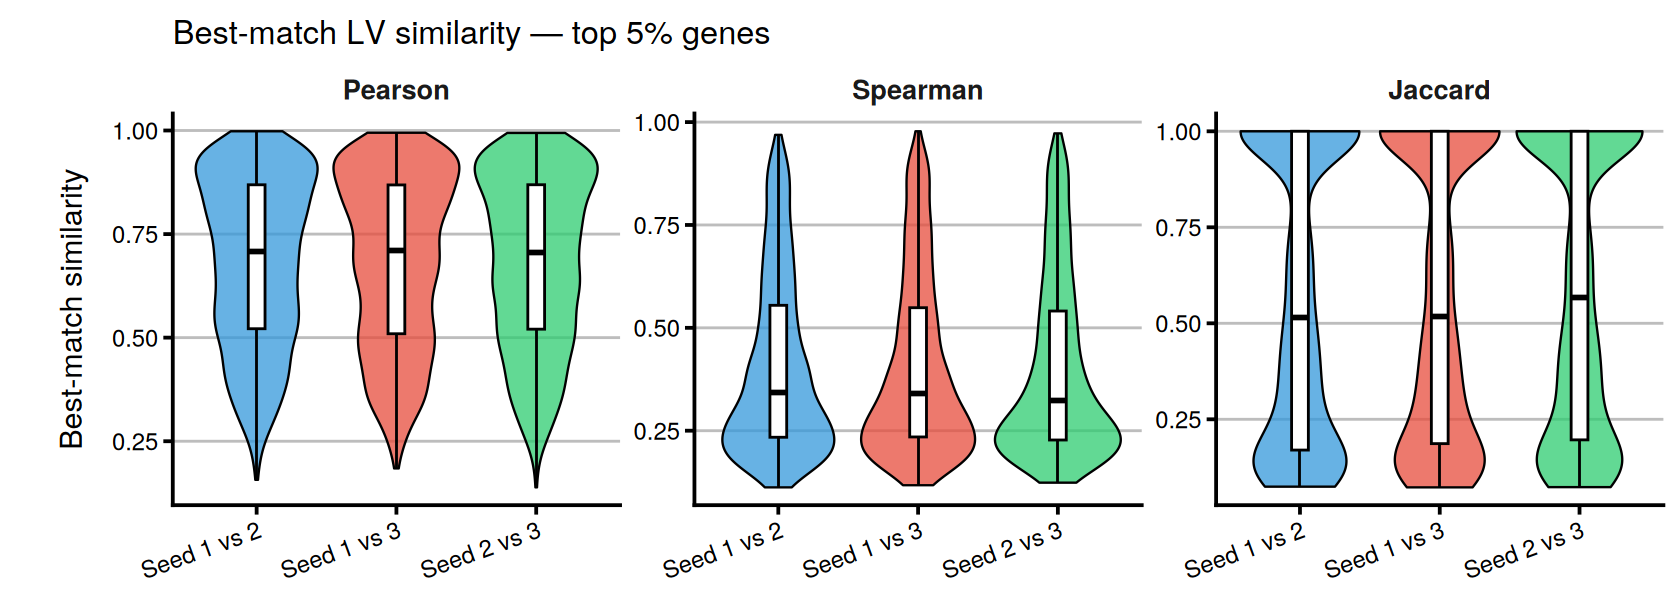

In [9]:
bm_long_5pct <- bind_rows(lapply(pair_labs, function(lab) {
  sm <- sim_5pct[[lab]]
  bind_rows(
    data.frame(pair = lab, method = "Pearson",  score = BestMatchScores(sm$pearson)),
    data.frame(pair = lab, method = "Spearman", score = BestMatchScores(sm$spearman)),
    data.frame(pair = lab, method = "Jaccard",  score = BestMatchScores(sm$jaccard))
  )
}))
bm_long_5pct$method <- factor(bm_long_5pct$method, levels = c("Pearson", "Spearman", "Jaccard"))
bm_long_5pct$pair   <- factor(bm_long_5pct$pair,   levels = pair_labs)

options(repr.plot.width = 14, repr.plot.height = 5)
ggplot(bm_long_5pct, aes(x = pair, y = score, fill = pair)) +
  geom_violin(trim = TRUE, alpha = 0.75, colour = "black", linewidth = 0.5) +
  geom_boxplot(width = 0.12, fill = "white", colour = "black",
               linewidth = 0.6, outlier.shape = NA) +
  facet_wrap(~method, scales = "free_y") +
  scale_fill_manual(values = pal) +
  labs(x = NULL, y = "Best-match similarity",
       title = "Best-match LV similarity: top 5% genes") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 20, hjust = 1), legend.position = "none")

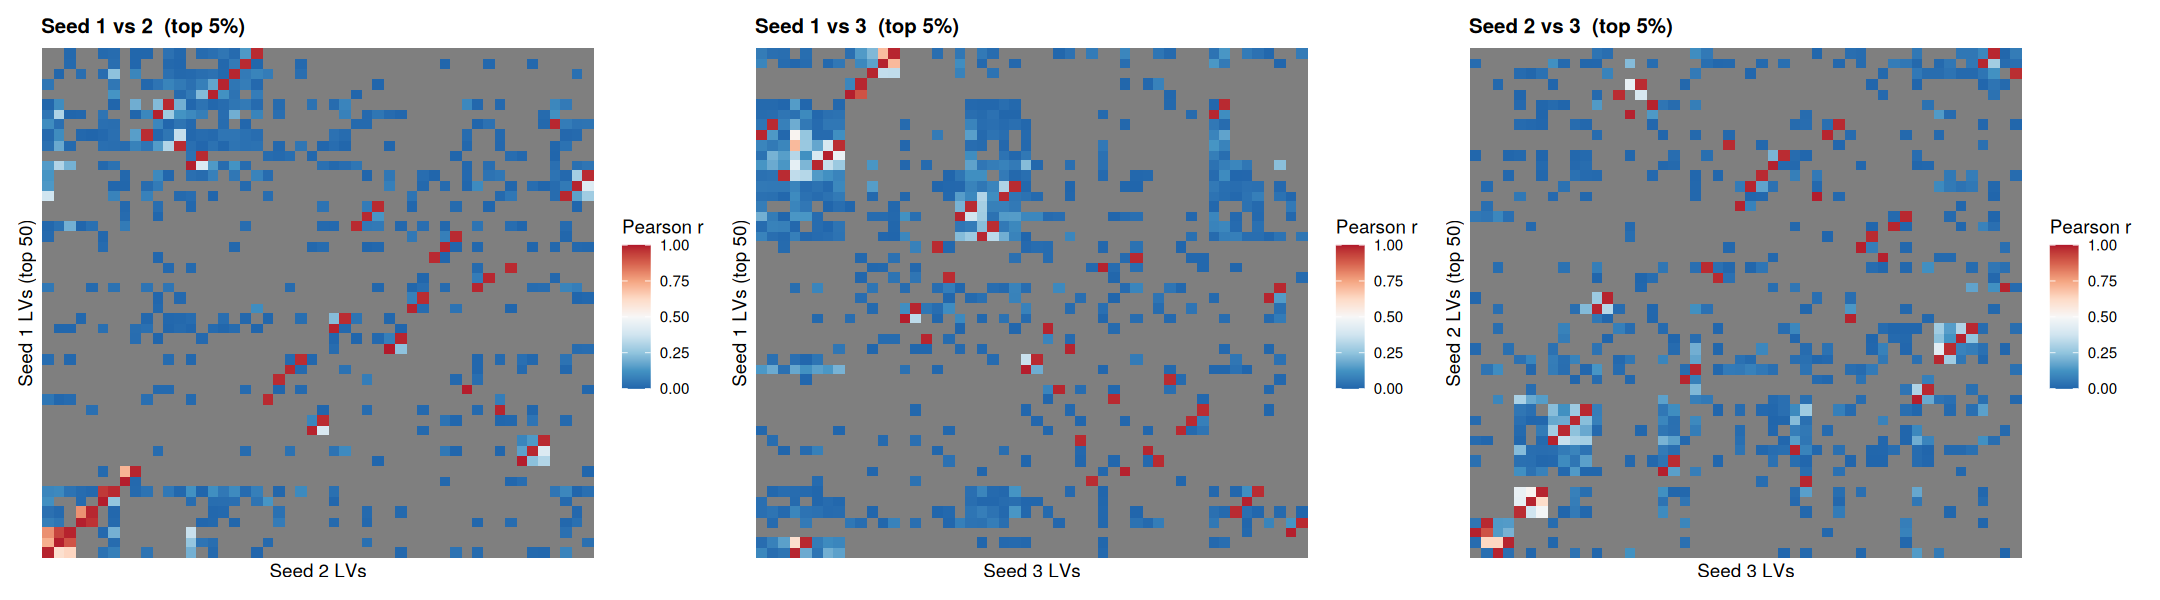

In [10]:
hp_5pct <- lapply(seq_along(pair_idx), function(k) {
  i <- pair_idx[[k]][1];  j <- pair_idx[[k]][2];  lab <- pair_labs[k]
  df <- MakeTopHeatmapDF(sim_5pct[[lab]]$pearson, TOP_N)
  sub     <- matrix(df$cor, nrow = length(unique(df$lv_a)), ncol = length(unique(df$lv_b)),
                    dimnames = list(unique(df$lv_a), unique(df$lv_b)))
  df$lv_a <- factor(df$lv_a, levels = rownames(sub)[hclust(dist(sub))$order])
  df$lv_b <- factor(df$lv_b, levels = colnames(sub)[hclust(dist(t(sub)))$order])
  ggplot(df, aes(x = lv_b, y = lv_a, fill = cor)) +
    geom_tile(colour = NA) +
    scale_fill_gradientn(colours = rev(RColorBrewer::brewer.pal(9, "RdBu")),
                         limits = c(0, 1), name = "Pearson r") +
    labs(title = paste0(lab, "  (top 5%)"),
         x = paste0("Seed ", j, " LVs"), y = paste0("Seed ", i, " LVs (top ", TOP_N, ")")) +
    theme_classic(base_size = 11) +
    theme(axis.text = element_blank(), axis.ticks = element_blank(),
          axis.line = element_blank(), plot.title = element_text(face = "bold", size = 12))
})

options(repr.plot.width = 18, repr.plot.height = 5)
wrap_plots(hp_5pct, nrow = 1)

In [11]:
JaccardCrossSimMat <- function(Za, Zb, pct = 0.05) {
  Za <- as.matrix(Za)
  Zb <- as.matrix(Zb)

  if (nrow(Za) != nrow(Zb)) {
    stop("Za and Zb must have the same number of rows (genes).")
  }

  if (!is.null(rownames(Za)) && !is.null(rownames(Zb))) {
    common_genes <- intersect(rownames(Za), rownames(Zb))
    if (length(common_genes) == 0) {
      stop("Za and Zb do not share rownames.")
    }
    Za <- Za[common_genes, , drop = FALSE]
    Zb <- Zb[common_genes, , drop = FALSE]
    gene_ids <- common_genes
  } else {
    gene_ids <- seq_len(nrow(Za))
  }

  n_top <- max(1, ceiling(nrow(Za) * pct))
  Ka <- ncol(Za)
  Kb <- ncol(Zb)

  out <- matrix(NA_real_, nrow = Ka, ncol = Kb)

  top_sets_a <- lapply(seq_len(Ka), function(i) {
    gene_ids[order(Za[, i], decreasing = TRUE)[seq_len(n_top)]]
  })

  top_sets_b <- lapply(seq_len(Kb), function(j) {
    gene_ids[order(Zb[, j], decreasing = TRUE)[seq_len(n_top)]]
  })

  for (i in seq_len(Ka)) {
    for (j in seq_len(Kb)) {
      inter <- length(intersect(top_sets_a[[i]], top_sets_b[[j]]))
      uni   <- length(union(top_sets_a[[i]], top_sets_b[[j]]))
      out[i, j] <- if (uni == 0) NA_real_ else inter / uni
    }
  }

  rownames(out) <- colnames(Za)
  colnames(out) <- colnames(Zb)
  out
}

In [12]:
sim_5pct    <- list()
global_rows <- list()

for (k in seq_along(pair_idx)) {
  i <- pair_idx[[k]][1]
  j <- pair_idx[[k]][2]
  lab <- pair_labs[k]

  Za <- Z_list[[i]]
  Zb <- Z_list[[j]]

  message("[5% | ", lab, "]")
  message("  Pearson ...")
  pc_mat <- CrossCorTopK(Za, Zb, pct = 0.05, method = "pearson")
  message("  Spearman ...")
  sp_mat <- CrossCorTopK(Za, Zb, pct = 0.05, method = "spearman")
  message("  Jaccard ...")
  jc_mat <- JaccardCrossSimMat(Za, Zb, pct = 0.05)

  sim_5pct[[lab]] <- list(
    pearson = pc_mat,
    spearman = sp_mat,
    jaccard = jc_mat
  )

  global_rows[[k]] <- data.frame(
    pair = lab,
    pearson_global = mean(c(BestMatchScores(pc_mat), BestMatchScores(t(pc_mat)))),
    spearman_global = mean(c(BestMatchScores(sp_mat), BestMatchScores(t(sp_mat)))),
    jaccard_global = mean(c(BestMatchScores(jc_mat), BestMatchScores(t(jc_mat)))),
    stringsAsFactors = FALSE
  )
}

global_df_5pct <- do.call(rbind, global_rows)
rownames(global_df_5pct) <- NULL
print(global_df_5pct)

[5% | Seed 1 vs 2]

  Pearson ...

  Spearman ...

  Jaccard ...

[5% | Seed 1 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...

[5% | Seed 2 vs 3]

  Pearson ...

  Spearman ...

  Jaccard ...



         pair pearson_global spearman_global jaccard_global
1 Seed 1 vs 2      0.6915699       0.4088658      0.3209338
2 Seed 1 vs 3      0.6918645       0.4080789      0.3255920
3 Seed 2 vs 3      0.6909540       0.4025853      0.3231820


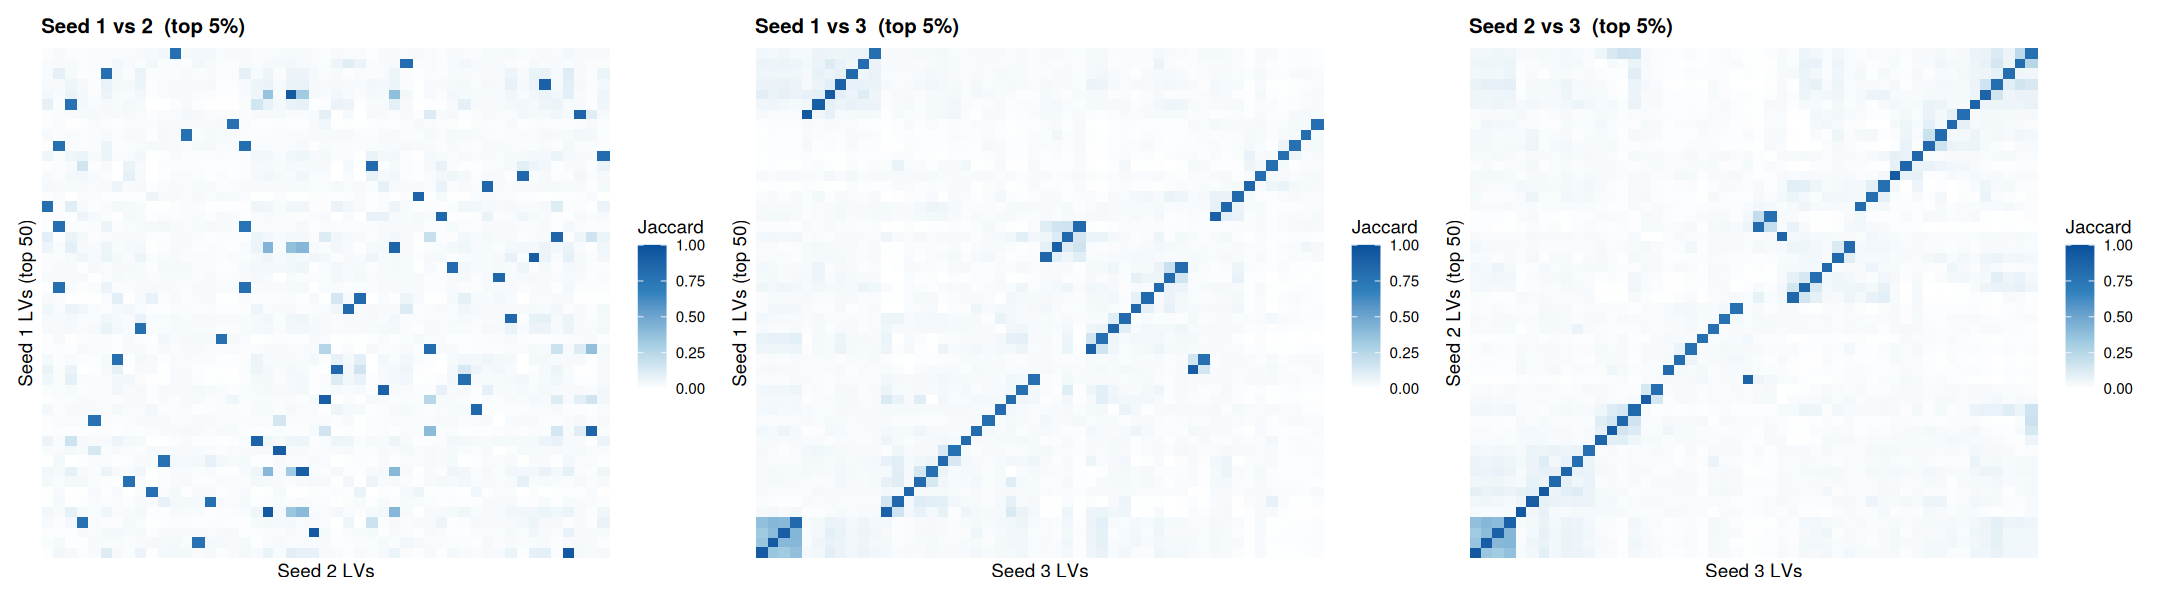

In [13]:
hp_5pct_jaccard <- lapply(seq_along(pair_idx), function(k) {
  i <- pair_idx[[k]][1]
  j <- pair_idx[[k]][2]
  lab <- pair_labs[k]

  df <- MakeTopHeatmapDF(sim_5pct[[lab]]$jaccard, TOP_N)

  sub <- matrix(
    df$cor,
    nrow = length(unique(df$lv_a)),
    ncol = length(unique(df$lv_b)),
    dimnames = list(unique(df$lv_a), unique(df$lv_b))
  )

  df$lv_a <- factor(df$lv_a, levels = rownames(sub)[hclust(dist(sub))$order])
  df$lv_b <- factor(df$lv_b, levels = colnames(sub)[hclust(dist(t(sub)))$order])

  ggplot(df, aes(x = lv_b, y = lv_a, fill = cor)) +
    geom_tile(colour = NA) +
    scale_fill_gradientn(
      colours = c("white", "#9ecae1", "#3182bd", "#08519c"),
      limits = c(0, 1),
      name = "Jaccard"
    ) +
    labs(
      title = paste0(lab, "  (top 5%)"),
      x = paste0("Seed ", j, " LVs"),
      y = paste0("Seed ", i, " LVs (top ", TOP_N, ")")
    ) +
    theme_classic(base_size = 11) +
    theme(
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      axis.line = element_blank(),
      plot.title = element_text(face = "bold", size = 12)
    )
})

options(repr.plot.width = 18, repr.plot.height = 5)
wrap_plots(hp_5pct_jaccard, nrow = 1)

---
## 2. Pathway overlap: summary (FDR < 0.05, AUC > 0.7)

Load the `summary` slot from each model, apply significance filters, and compare which pathways are recovered across seeds.

In [14]:
FDR_CUT <- 0.05
AUC_CUT <- 0.70

summaries <- lapply(names(models), function(nm) {
  df <- data.frame(as.matrix(models[[nm]]$summary), stringsAsFactors = FALSE)
  df %>%
    mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    filter(FDR < FDR_CUT, AUC > AUC_CUT) %>%
    mutate(seed = nm)
})
names(summaries) <- names(models)

for (nm in names(summaries)) {
  s <- summaries[[nm]]
  message(nm,
          "  sig LV-pathway pairs: ", nrow(s),
          "  unique pathways: ", length(unique(s$pathway)),
          "  unique LVs: ",      length(unique(s$LV)))
}

# Unique significant pathways per seed
pathway_sets <- lapply(summaries, function(df) unique(df$pathway))

seed_1  sig LV-pathway pairs: 1794  unique pathways: 899  unique LVs: 657

seed_2  sig LV-pathway pairs: 1660  unique pathways: 872  unique LVs: 621

seed_3  sig LV-pathway pairs: 1759  unique pathways: 914  unique LVs: 650



In [15]:
# Intersection counts
s1 <- pathway_sets[["seed_1"]]
s2 <- pathway_sets[["seed_2"]]
s3 <- pathway_sets[["seed_3"]]

only1    <- length(setdiff(s1, union(s2, s3)))
only2    <- length(setdiff(s2, union(s1, s3)))
only3    <- length(setdiff(s3, union(s1, s2)))
int12    <- length(setdiff(intersect(s1, s2), s3))
int13    <- length(setdiff(intersect(s1, s3), s2))
int23    <- length(setdiff(intersect(s2, s3), s1))
int_all  <- length(Reduce(intersect, list(s1, s2, s3)))

summary_tbl <- data.frame(
  intersection  = c("Only seed 1", "Only seed 2", "Only seed 3",
                    "Seed 1 & 2",  "Seed 1 & 3",  "Seed 2 & 3",
                    "All three"),
  n_pathways    = c(only1, only2, only3, int12, int13, int23, int_all)
)
print(summary_tbl)

  intersection n_pathways
1  Only seed 1        134
2  Only seed 2        115
3  Only seed 3        138
4   Seed 1 & 2         95
5   Seed 1 & 3        114
6   Seed 2 & 3        106
7    All three        556


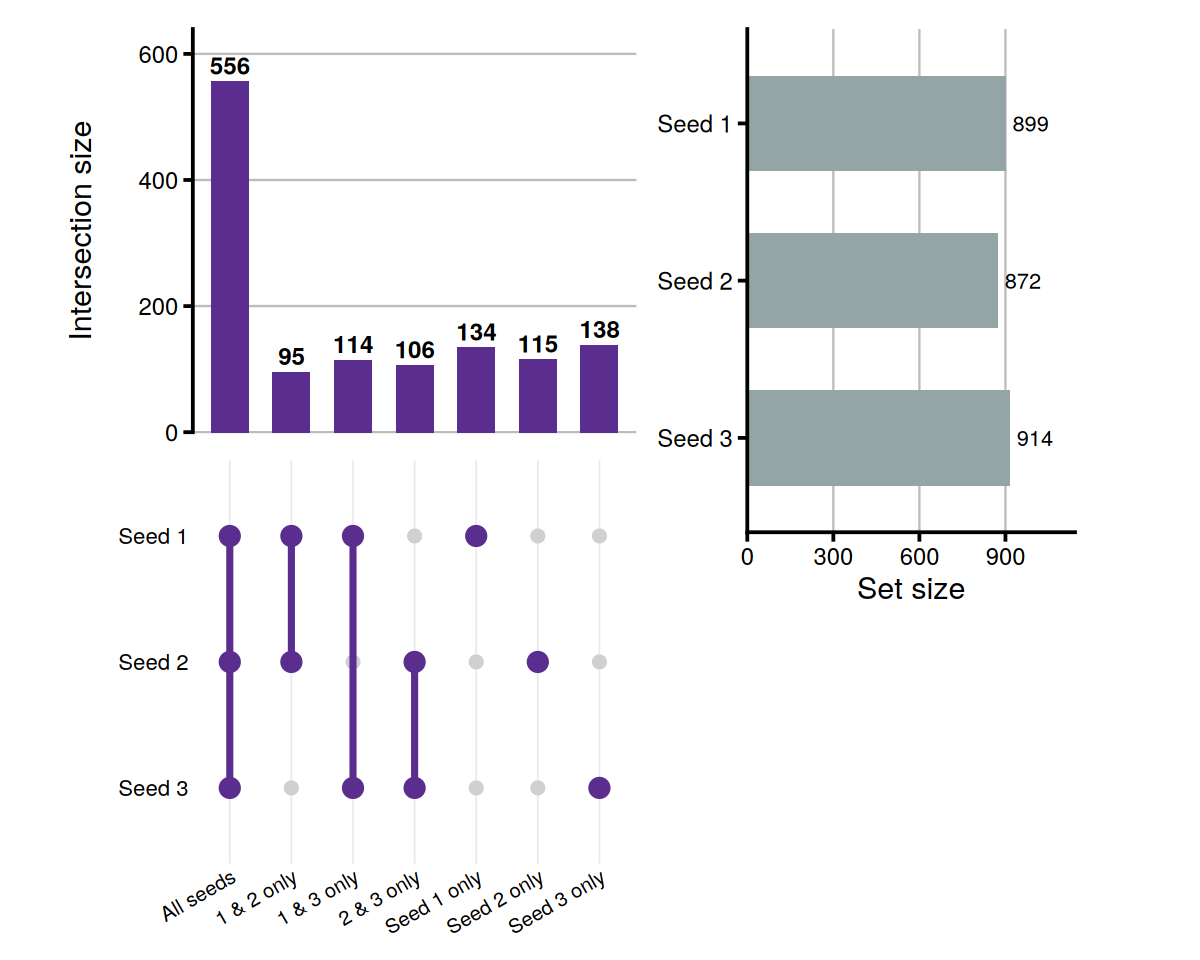

In [16]:
# ── UpSet plot (ggplot2 implementation) ───────────────────────────────────────
options(repr.plot.width = 10, repr.plot.height = 8)

all_pathways <- Reduce(union, pathway_sets)

# Membership matrix (pathways x seeds)
mem_df <- data.frame(
  pathway = all_pathways,
  seed_1  = all_pathways %in% s1,
  seed_2  = all_pathways %in% s2,
  seed_3  = all_pathways %in% s3
)

# Encode intersection as string label
mem_df <- mem_df %>%
  mutate(combo = paste0(
    ifelse(seed_1, "1", "0"),
    ifelse(seed_2, "1", "0"),
    ifelse(seed_3, "1", "0")
  ))

# Intersection sizes
inter_counts <- mem_df %>%
  group_by(combo) %>%
  summarise(n = n(), .groups = "drop") %>%
  arrange(desc(n))

# Human-readable labels
combo_label <- c(
  "111" = "All seeds",
  "110" = "1 & 2 only",
  "101" = "1 & 3 only",
  "011" = "2 & 3 only",
  "100" = "Seed 1 only",
  "010" = "Seed 2 only",
  "001" = "Seed 3 only"
)
inter_counts <- inter_counts %>%
  mutate(label = combo_label[combo]) %>%
  mutate(label = factor(label, levels = combo_label[combo_label %in% label]))

# Dot-matrix data
set_names_upset <- c("Seed 1", "Seed 2", "Seed 3")
dot_df <- inter_counts %>%
  mutate(
    s1_in = substr(combo, 1, 1) == "1",
    s2_in = substr(combo, 2, 2) == "1",
    s3_in = substr(combo, 3, 3) == "1"
  ) %>%
  tidyr::pivot_longer(cols = c(s1_in, s2_in, s3_in),
                      names_to = "set_var", values_to = "active") %>%
  mutate(set_label = factor(
    recode(set_var, s1_in = "Seed 1", s2_in = "Seed 2", s3_in = "Seed 3"),
    levels = rev(set_names_upset)
  ))

# Bar chart (top)
bar_col <- "#5b2d8e"

p_bar <- ggplot(inter_counts, aes(x = label, y = n)) +
  geom_col(fill = bar_col, width = 0.6) +
  geom_text(aes(label = n), vjust = -0.4, size = 5, fontface = "bold") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(x = NULL, y = "Intersection size") +
  theme_ng() +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line.x = element_blank(),
        panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.5))

# Dot matrix (bottom)
p_dot <- ggplot(dot_df, aes(x = label, y = set_label)) +
  geom_point(aes(colour = active, size = active)) +
  # connect active dots with a vertical line
  geom_line(
    data = dot_df %>% filter(active),
    aes(group = label),
    colour = bar_col,
    linewidth = 1.5
  ) +
  scale_colour_manual(values = c("FALSE" = "#d0d0d0", "TRUE" = bar_col)) +
  scale_size_manual(values   = c("FALSE" = 3, "TRUE" = 5)) +
  labs(x = NULL, y = NULL) +
  theme_classic(base_size = 14) +
  theme(legend.position = "none",
        axis.text.x     = element_text(angle = 30, hjust = 1, size = 12),
        axis.text.y     = element_text(size = 13),
        axis.line       = element_blank(),
        axis.ticks      = element_blank(),
        panel.grid.major.x = element_line(colour = "#ebebeb", linewidth = 0.4))

# Set size bar (right side, horizontal)
set_size_df <- data.frame(
  set_label = factor(set_names_upset, levels = rev(set_names_upset)),
  n         = c(length(s1), length(s2), length(s3))
)

p_set <- ggplot(set_size_df, aes(x = set_label, y = n)) +
  geom_col(fill = "#95a5a6", width = 0.6) +
  geom_text(aes(label = n), hjust = -0.2, size = 4.5) +
  coord_flip() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.25))) +
  labs(x = NULL, y = "Set size") +
  theme_ng() +
  theme(panel.grid.major.y = element_blank(),
        panel.grid.major.x = element_line(colour = "#BDBDBD", linewidth = 0.5))

# Combine with patchwork
(p_bar / p_dot) | p_set +
  plot_layout(widths = c(3, 1), heights = c(2, 1)) &
  theme(plot.margin = margin(4, 4, 4, 4))

In [17]:
# ── Shared pathway list ────────────────────────────────────────────────────────
shared_all <- Reduce(intersect, pathway_sets)
message("Pathways recovered in all 3 seeds: ", length(shared_all))

# Show proportion shared
prop_shared <- length(shared_all) / length(Reduce(union, pathway_sets))
message(sprintf("Proportion of union recovered in all 3: %.1f%%", prop_shared * 100))

Pathways recovered in all 3 seeds: 556

Proportion of union recovered in all 3: 44.2%

